# Кредитный скоринг на данных кредитных историй
https://www.kaggle.com/competitions/alfa-bank-pd-credit-history/overview  
**Этот проектик можно рассматривать как изучение конкретной задачи в дс/мл** _(я учусь только такое решать еще)_
## Задача
В этом соревновании участникам предлагается решить задачу кредитного скоринга клиентов Альфа-Банка, используя только данные кредитных историй.
## Данные

Датасет соревнования устроен таким образом, что кредиты для тренировочной выборки взяты за период в М месяцев, а кредиты для тестовой выборки взяты за последующие K месяцев.

Каждая запись кредитной истории содержит самую разнообразную информацию о прошлом кредите клиента, например, сумму, отношение клиента к кредиту, дату открытия и закрытия, информацию о просрочках по платежам и др. Все публикуемые данные тщательно анонимизированы.

Целевая переменная – бинарная величина, принимающая значения 0 и 1, где 1 соответствует дефолту клиента по кредиту.

Подробное описание файлов и полей датасета соревнования участники могут найти во вкладке Data.
Проверка решений

**Метрика соревнования – ROC AUC.**

## 0. Импорты

In [16]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

from optbinning.binning import BinningProcess

# 1. Подготовка данных
Грубо говоря здесь нужно отделять данные и определять дефолт, но это за меня сделано уже.  
Вкратце как оно обычно проиходит.
- **Определение дефолта (Target):** Задается строгий критерий невозврата. Обычно это непрерывная просрочка 90+ дней (DPD 90+) в рамках заданного окна наблюдения (например, первые 12 месяцев жизни кредита).
- **Маркировка выборки:**
    - 1 (Bad) — клиент допустил просрочку 90+ дней.
    - 0 (Good) — клиент платил исправно весь год.
    - Исключение (Indeterminate) — клиенты с мелкой просрочкой (15–30 дней). Они удаляются из выборки, чтобы модель обучалась на контрастных примерах
- **Временной сплит (Sampling):** Данные делятся по дате выдачи кредита:
    - Train / Validation (70/30): Исторический пласт (например, январь — октябрь 2024 г.) для обучения и настройки.
    - Out-of-Time / OOT (Тест): Более поздний закрытый период (ноябрь — декабрь 2024 г.) для симуляции работы модели в реальных условиях.

In [17]:
NTRAINFILES = 12

files = [f"train_data/train_data_{i}.pq" for i in range(NTRAINFILES)]
arrow_table_train = pq.read_table(files)
X_train = arrow_table_train.to_pandas()

In [18]:
print(f"X_train shape: {X_train.shape}")
print(X_train.info())
print(X_train.isnull().sum())
print(f"Null count: {X_train.isnull().sum().sum()}")

X_train shape: (26162717, 61)
<class 'pandas.DataFrame'>
RangeIndex: 26162717 entries, 0 to 26162716
Data columns (total 61 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int64
 1   rn                             int64
 2   pre_since_opened               int64
 3   pre_since_confirmed            int64
 4   pre_pterm                      int64
 5   pre_fterm                      int64
 6   pre_till_pclose                int64
 7   pre_till_fclose                int64
 8   pre_loans_credit_limit         int64
 9   pre_loans_next_pay_summ        int64
 10  pre_loans_outstanding          int64
 11  pre_loans_total_overdue        int64
 12  pre_loans_max_overdue_sum      int64
 13  pre_loans_credit_cost_rate     int64
 14  pre_loans5                     int64
 15  pre_loans530                   int64
 16  pre_loans3060                  int64
 17  pre_loans6090                  int64
 18  pre_loans90          

id                         0
rn                         0
pre_since_opened           0
pre_since_confirmed        0
pre_pterm                  0
                          ..
enc_loans_credit_status    0
enc_loans_credit_type      0
enc_loans_account_cur      0
pclose_flag                0
fclose_flag                0
Length: 61, dtype: int64
Null count: 0


In [19]:
NTESTFILES = 2

files = [f"test_data/test_data_{i}.pq" for i in range(NTESTFILES)]
arrow_table_test = pq.read_table(files)
X_test = arrow_table_test.to_pandas()

In [20]:
print(f"X_test shape: {X_test.shape}")
print(X_test.info())
print(X_test.isnull().sum())
print(f"Null count: {X_test.isnull().sum().sum()}")

X_test shape: (4724601, 61)
<class 'pandas.DataFrame'>
RangeIndex: 4724601 entries, 0 to 4724600
Data columns (total 61 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int64
 1   rn                             int64
 2   pre_since_opened               int64
 3   pre_since_confirmed            int64
 4   pre_pterm                      int64
 5   pre_fterm                      int64
 6   pre_till_pclose                int64
 7   pre_till_fclose                int64
 8   pre_loans_credit_limit         int64
 9   pre_loans_next_pay_summ        int64
 10  pre_loans_outstanding          int64
 11  pre_loans_total_overdue        int64
 12  pre_loans_max_overdue_sum      int64
 13  pre_loans_credit_cost_rate     int64
 14  pre_loans5                     int64
 15  pre_loans530                   int64
 16  pre_loans3060                  int64
 17  pre_loans6090                  int64
 18  pre_loans90              

In [21]:
y_train = pd.read_csv("train_target.csv")

In [22]:
print(f"y_train shape: {y_train.shape}")
print(y_train.info())

y_train shape: (3000000, 2)
<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 2 columns):
 #   Column  Dtype
---  ------  -----
 0   id      int64
 1   flag    int64
dtypes: int64(2)
memory usage: 45.8 MB
None


In [23]:
y_test = pd.read_csv("test_target.csv")

In [24]:
print(f"y_test shape: {y_test.shape}")
print(y_test.info())

y_test shape: (500000, 1)
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   id      500000 non-null  int64
dtypes: int64(1)
memory usage: 3.8 MB
None


In [40]:
y_dict = y_train.set_index('id')['flag']
y_train_extended = X_train['id'].map(y_dict)
print(y_train_extended.shape)

(26162717,)


# 2. Трансформация признаков (биннинг, WOE)
На этом этапе непрерывные числа и текстовые категории переводятся на универсальный язык рисков — коэффициенты WOE.
- **Fine Binning (Первичная нарезка):** Каждый числовой признак делится на 10–20 мелких интервалов (квантилей).
- **Coarse Binning (Бизнес-укрупнение):** Смежные интервалы склеиваются алгоритмом оптимизации (например, MILP в библиотеке optbinning) с учетом жестких правил:  
    - Объем каждого получившегося бина — **не менее 5%** от всей выборки.
    - В каждом бине есть хотя бы один дефолт (нет дефолтов — будет деление на ноль).
    - **Монотонность тренда:** Доля дефолтов (Bad Rate) от бина к бину должна строго расти или строго падать (для исключений вроде U-образного риска возраста задается специальная кусочная монотонность).
- **Расчет WOE:** Каждому бину присваивается одно числовое значение:  
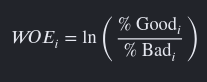  
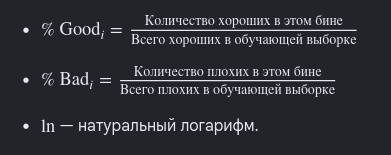  
Все сырые значения в датасете (рубли, года) перезаписываются этими коэффициентами. Пропуски (NaN) выделяются в отдельный бин со своим WOE.

# 3. Отбор признаков (IV)
- **Фильтрация по силе признака (Information Value — IV):** Для каждого фактора рассчитывается суммарный IV.  
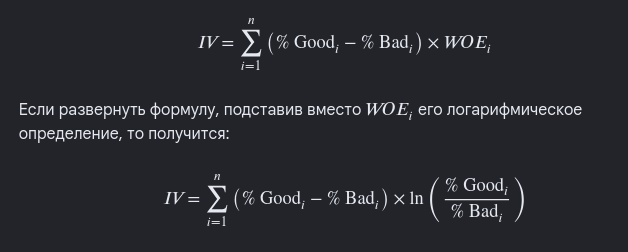  
    - Признаки с \(IV < 0.02\) (мусорные) — удаляются.
    - Признаки с \(IV > 0.5\) проверяются на Data Leakage (утечку ответов из будущего) и чаще всего удаляются.
    - В работу уходят факторы со средней и высокой силой (\(0.1 \le IV < 0.5\)).
- **Проверка на мультиколлинеарность:** 
    - Строится матрицу корреляции WOE-переменных. Если парная корреляция между факторами \(> 0.5–0.6\), оставляют один признак с наибольшим IV.
    - Рассчитывается фактор инфляции дисперсии (VIF). Он должен быть строго \(<5\).  
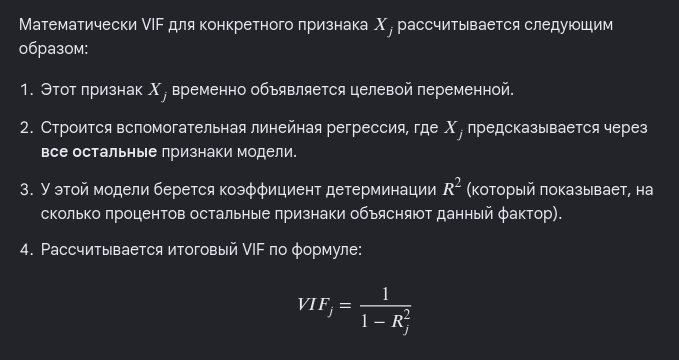  
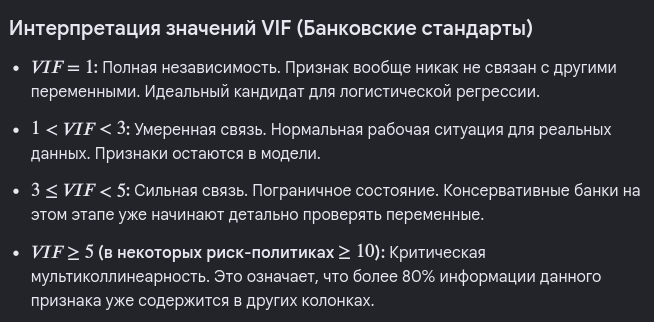  

# 4. Обучение модели (в нашем случае логистической регресии)
На вход подаются оставшиеся 8–15 «чистых» WOE-признаков. Алгоритм находит веса (\(\beta \)) для уравнения логарифма шансов дефолта. Все \(\beta \) обязаны получиться положительными.  
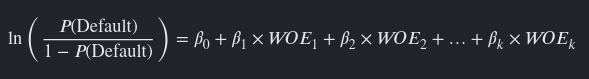

# 5. Скейлинг (Создание скоринговой карты)
Превращение формулы регрессии в понятную человеку таблицу баллов.
- **Фиксация бизнес-констант:** Бизнес задает три параметра:
    - Base Score (например, 600 баллов).
    - Base Odds (например, шансы 50:1, что соответствует среднему риску портфеля).
    - PDO (шаг удваивания шансов, например, 20 баллов).  
- **Пересчет весов:** С помощью математических коэффициентов (*Factor* и *Offset*) веса регрессии \(\beta \) и значения \(WOE\) каждого бина пересчитываются в целые числа — баллы.  
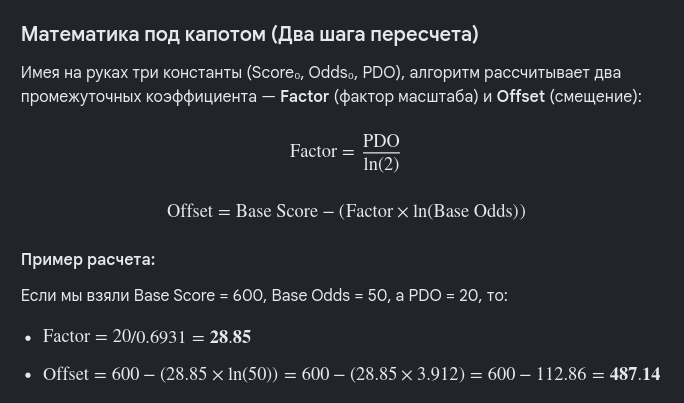  
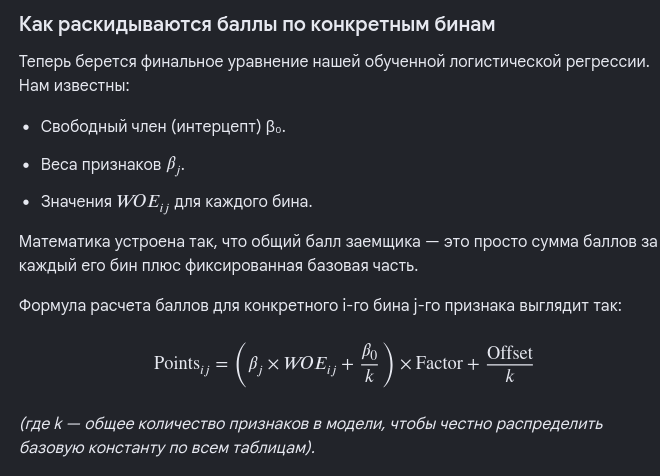  
- **Формирование Scorecard:** На выходе получается итоговая таблица (карта), где за каждый интервал дохода или возраста клиенту положен фиксированный балл (например: Возраст 25–35 лет \(\rightarrow \) +45 баллов). Общий сколл-балл — это простая сумма баллов по всем факторам.  
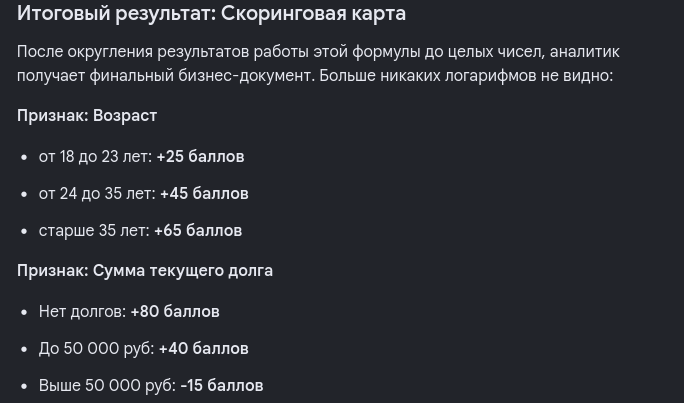  